<style type="text/css">
.tf  {border-collapse:collapse;border-spacing:0;width:100%}
.tf td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tf th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tf .tg-0pky{border-color:inherit;text-align:left;vertical-align:top}
.col1 { width: 20%;}
.col2 { width: 80%;}
</style>
<table class="tf">
<thead>
  <tr>
    <th class="tg-0pky col1">Name</th>
    <th class="tg-0pky col2">Vineet Parmar</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td class="tg-0pky col1">UID No.</td>
    <td class="tg-0pky col2">2021300092</td>
  </tr>
  <tr>
    <td class="tg-0pky col1">Course</td>
    <td class="tg-0pky col2">Advanced Data Visualization</td>
  </tr>
</tbody>
</table>

## <p style="text-align:center;font-weight:500;">Experiment 1</p>
<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;width:100%}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 10px;word-break:normal;}
.tg .tg-0pky{border-color:inherit;text-align:left;vertical-align:top;}
.col1 { width: 20%;}
.col2 { width: 80%;}
</style>
<table class="tg">
<thead>
  <tr>
    <th class="tg-0pky col1">Aim</th>
    <th class="tg-0pky col2"> 
      Create basic charts using Tableau / Power BI / R / Python / D3.js to be performed on the dataset of Ecommerce field
      <br>
      Complete all plots on practice dataset and reproduce on e-commerce dataset.
      <br>
      Basic - Bar chart, Pie chart, Histogram, Timeline chart, Scatter plot, Bubble plot 
      <br>
      Calculate Product wise sales, region wise sales
      <br>
      Write observations from each chart
    </th>
  </tr>
</thead>
</table> 

### 1. Importing Libraries and Dataset

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Dataset** You can view the dataset [here](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/data)

**Description**  
This dataset contains the details of Amazon Sales. It provides detailed insights into Amazon sales data, including SKU Code, Design Number, Stock, Category, Size and Color, to help optimize product profitability. It has 23 columns:  

**Category:** Type of product. (String)  
**Size:** Size of the product. (String)  
**Date:** Date of the sale. (Date)  
**Status:** Status of the sale. (String)  
**Fulfilment:** Method of fulfilment. (String)  
**Style:** Style of the product. (String)  
**SKU:** Stock Keeping Unit. (String)  
**ASIN:** Amazon Standard Identification Number. (String)  
**Courier Status:** Status of the courier. (String)  
**Qty:** Quantity of the product. (Integer)  
**Amount:** Amount of the sale. (Float)  
**B2B:** Business to business sale. (Boolean)  
**Currency:** The currency used for the sale. (String)

In [33]:
data = pd.read_csv("../Datasets/Amazon Sale Report.csv", low_memory=False, index_col=0)
print(data.shape)
data.head()

(128975, 23)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


<p style="page-break-after:always;"></p>

### 2. Data Preprocessing

In [34]:
# delete last column
data = data.iloc[:, :-1]

In [39]:
# check for missing values
data.isnull().sum()

Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier Status           0
Qty                      0
currency              7793
Amount                7793
ship-city               28
ship-state              28
ship-postal-code        28
ship-country            28
B2B                      0
dtype: int64

In [36]:
# delete columns: 'fulfilled-by' and 'promotion-ids'
data = data.drop(['fulfilled-by', 'promotion-ids'], axis=1)

In [38]:
# delete rows with more than 20% missing values
data = data.dropna(thresh=data.shape[1]*0.80)

# replace nan in courier status with same value as in status
data['Courier Status'] = data['Courier Status'].fillna(data['Status'])

In [40]:
print(data.shape)
data.head()

(128970, 20)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
index,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Cancelled,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Cancelled,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False


In [41]:
# save cleaned data
data.to_csv("../Datasets/Amazon_Sales_cleaned.csv")

<p style="page-break-after:always;"></p>

### 3. Charts & Plots

In [42]:
df = pd.read_csv("../Datasets/Amazon_Sales_cleaned.csv", index_col=0)
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
index,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Cancelled,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Cancelled,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False


##### 3.1 Bar Chart

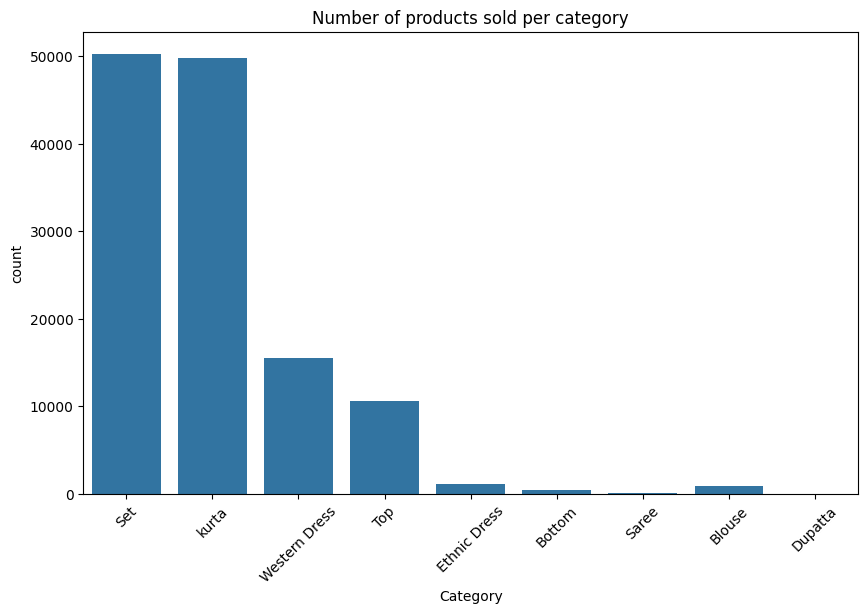

In [46]:
# make a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category')
plt.xticks(rotation=45)
plt.title('Number of products sold per category')
plt.show()

**Oberservation:**  
- The bar chart shows the total sales of each product category.
- The category 'Set' has the highest sales, followed by 'Kurta' and 'Western Dress'.
- The category 'Dupatta' has the lowest sales.

This suggests that the 'Set' category is the most popular among customers and should be focused on more.

##### 3.2 Pie Chart

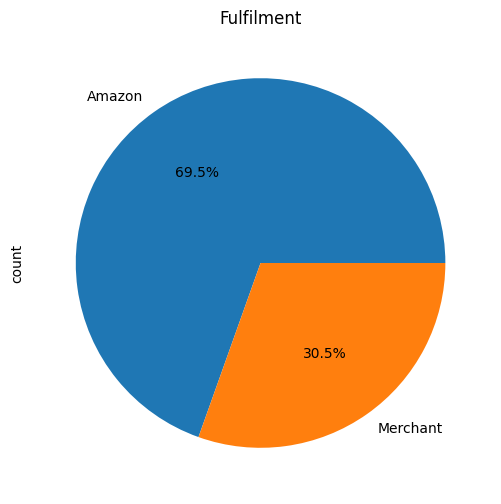

In [52]:
# make a pie chart for ship-service-level
plt.figure(figsize=(10, 6))
df['Fulfilment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Fulfilment')
plt.show()

**Oberservation:**  
- The pie chart shows how much percentage of orders are fulfilled by each method.
- Most Orders are Fullfilled by Amazon itself followed by others being fulfilled by the seller (Merchant).

This suggests that Amazon should focus on improving its own fulfilment services.

##### 3.3 Histogram

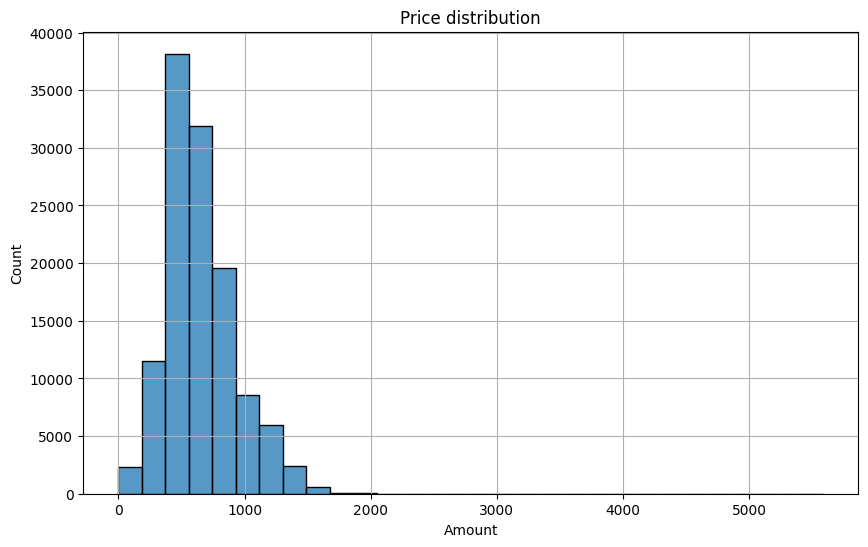

In [61]:
# make a histogram for price
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=30)
plt.title('Price distribution')
plt.grid()
plt.show()

**Oberservation:**  
- The histogram shows the distribution of the price per product.
- Most products are priced between 0 and $1000.

This suggests that most products are priced reasonably and are affordable to customers.

##### 3.4 Timeline Chart

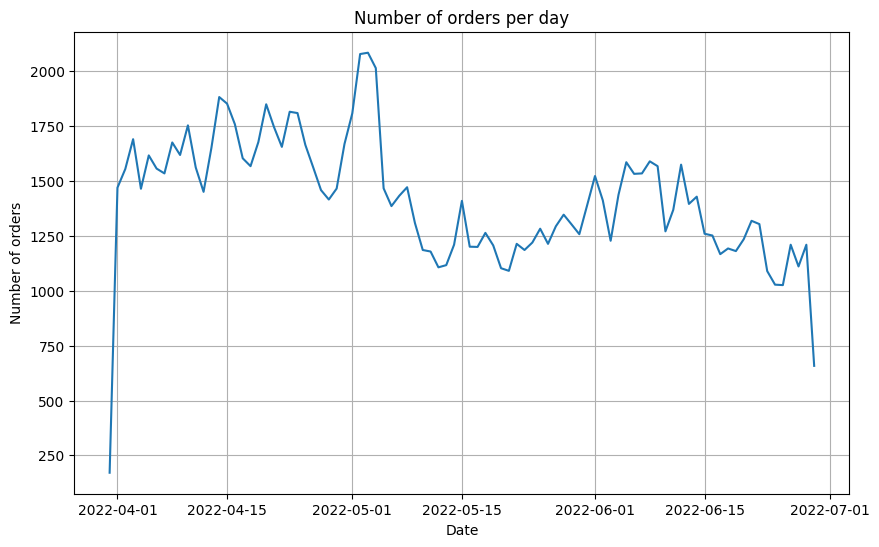

In [58]:
# make a time series plot for order date
plt.figure(figsize=(10, 6))
df['Date'] = pd.to_datetime(df['Date'])

# group by date
df_grouped = df.groupby('Date').size().reset_index(name='Count')

plt.plot(df_grouped['Date'], df_grouped['Count'])
plt.title('Number of orders per day')
plt.xlabel('Date')
plt.ylabel('Number of orders')
plt.grid(True)
plt.show()

**Oberservation:**  
- The timeline chart shows the sales trend over time.
- The sales peak in the month of May, out of the following months: April, May, June, July

This suggests that the month of May is the most profitable month for Amazon in the first quarter of the year owing to summer vacations.

##### 3.5 Scatter Plot

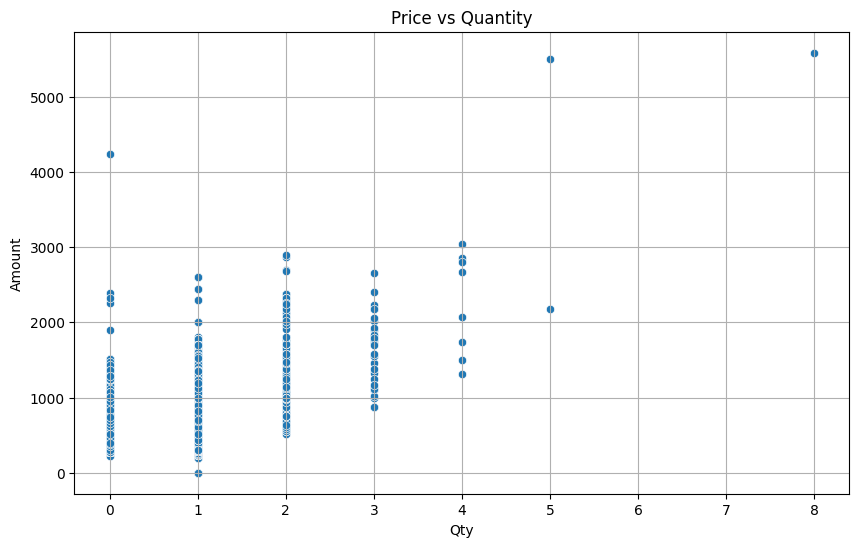

In [62]:
# make a scatter plot for price vs quantity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Qty', y='Amount')
plt.title('Price vs Quantity')
plt.grid()
plt.show()

**Oberservation:**  
- The scatter plot shows the relationship between the quantity of products sold and the amount of the sale.
- There is a positive correlation between the quantity of products sold and the amount of the sale.

##### 3.6 Bubble Plot

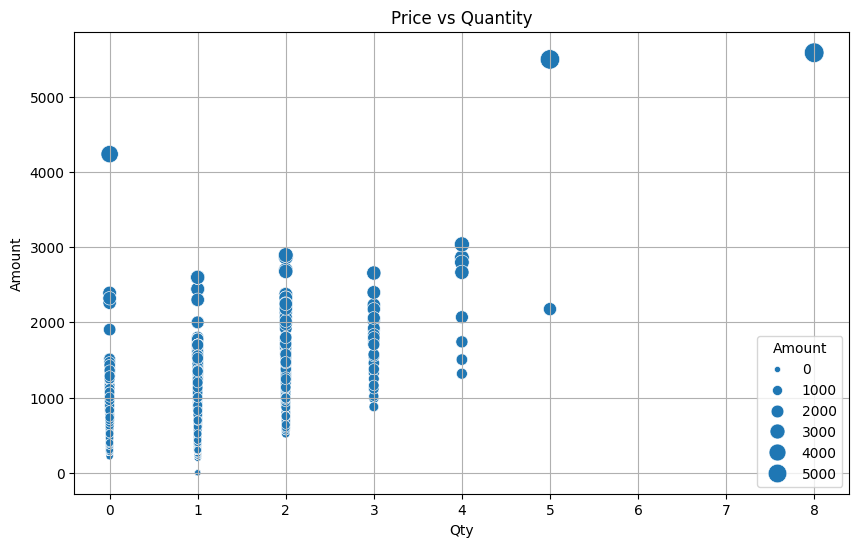

In [64]:
# make a bubble plot for price vs quantity

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Qty', y='Amount', size='Amount', sizes=(20, 200))
plt.title('Price vs Quantity')
plt.grid()
plt.show()

**Oberservation:**  
- The bubble plot shows the relationship between the quantity of products sold and the amount of the sale, with the size of the bubble representing the price of the product.
- The bubble plot confirms the positive correlation between the quantity of products sold and the amount of the sale.

<p style="page-break-after:always;"></p>

### Conclusion
In this experiment, we learned how to create basic charts using Pandas and Seaborn in Python on a dataset of the Ecommerce field. We created the following plots on the practice dataset and reproduced them on the e-commerce dataset: bar chart, pie chart, histogram, timeline chart, scatter plot, and bubble plot. We wrote observations from each chart to gain insights into the data.